# Customer Churn Analysis & Segmentation

**Goal:** Analyze customer behavior in an e-commerce dataset to understand churn drivers, and segment customers into actionable groups using K-Means clustering.

**Dataset:** `ecommerce_customer_churn_dataset.csv` — customer demographics, engagement, and purchase behavior with a binary `Churned` label.

**Approach:** Clean and validate the data → explore churn patterns via EDA → engineer activity/engagement features → segment customers with K-Means (validated via Elbow Method and Silhouette Score) → profile segments and connect them back to churn rate.

## 1. Data Loading & Initial Inspection

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [69]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [70]:
df=pd.read_csv("/content/ecommerce_customer_churn_dataset.csv")

In [71]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [72]:
df.shape

(50000, 25)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


## 2. Data Cleaning

Check for missing values, duplicates, and invalid/out-of-range entries before analysis.

In [75]:
df.isnull().sum().sort_values(ascending=False)

,0
Social_Media_Engagement_Score,6000
Credit_Balance,5500
Mobile_App_Usage,5000
Returns_Rate,4491
Wishlist_Items,4000
Product_Reviews_Written,3500
Discount_Usage_Rate,3500
Session_Duration_Avg,3399
Pages_Per_Session,3000
Days_Since_Last_Purchase,3000


In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (50000, 25)


In [78]:
df["Gender"].value_counts()

,count
Gender,
Female,25116
Male,23947
Other,937


In [79]:
df["Country"].value_counts()

,count
Country,
USA,17384
UK,7534
Canada,6023
Germany,4925
Australia,4061
France,4013
India,3512
Japan,2548


In [80]:
df.groupby("Country")["City"].unique()

,City
Country,
Australia,"[Adelaide, Sydney, Brisbane, Melbourne, Perth]"
Canada,"[Vancouver, Calgary, Ottawa, Montreal, Toronto]"
France,"[Marseille, Paris, Nice, Toulouse, Lyon]"
Germany,"[Berlin, Munich, Frankfurt, Cologne, Hamburg]"
India,"[Delhi, Bangalore, Mumbai, Hyderabad, Chennai]"
Japan,"[Tokyo, Yokohama, Nagoya, Osaka, Kyoto]"
UK,"[Manchester, Glasgow, Leeds, Birmingham, London]"
USA,"[New York, Houston, Phoenix, Los Angeles, Chic..."


In [81]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop("Churned")  # never impute the target
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [82]:
print(df.isnull().sum())

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64


In [83]:
df = df[(df["Age"] > 0) & (df["Age"] <= 100)]
df = df[df["Total_Purchases"] >= 0]
df = df[(df["Cart_Abandonment_Rate"] >= 0) & (df["Cart_Abandonment_Rate"] <= 100)]
df = df[df["Membership_Years"] >= 0]

In [84]:
print((df["Age"] == 200).sum())
print((df["Total_Purchases"]<0).sum())
print((df["Cart_Abandonment_Rate"]>100).sum())

0
0
0


In [85]:
df.shape

(49910, 25)

In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49910.0,37.757684,11.186004,5.00,30.0000,38.000,45.0000,75.000000
Membership_Years,49910.0,2.983478,2.058408,0.10,1.4000,2.500,4.0000,10.000000
Login_Frequency,49910.0,11.625927,7.810079,0.00,6.0000,11.000,17.0000,46.000000
Session_Duration_Avg,49910.0,27.603801,10.496202,1.00,20.2000,26.800,34.0000,75.600000
Pages_Per_Session,49910.0,8.718333,3.663447,1.00,6.2000,8.400,11.0000,24.100000
Cart_Abandonment_Rate,49910.0,57.045093,16.211100,0.00,46.4000,58.100,68.7000,100.000000
Wishlist_Items,49910.0,4.274955,3.060595,0.00,2.0000,4.000,6.0000,28.000000
Total_Purchases,49910.0,13.127808,6.998241,0.00,8.0000,12.000,17.0000,128.700000
Average_Order_Value,49910.0,123.118326,175.717088,26.38,87.0500,112.960,144.4400,9666.379178
Days_Since_Last_Purchase,49910.0,29.269245,28.871231,0.00,9.0000,21.000,39.0000,287.000000


## 3. Exploratory Data Analysis

High-level metrics and distributions to understand the customer base.

In [87]:
total_customers = df.shape[0]

churn_rate = (df["Churned"].mean()) * 100

avg_lifetime_value = (df["Lifetime_Value"].mean())

avg_purchase = (df["Total_Purchases"].mean())

print("Total Customers:", total_customers)

print("Churn Rate:", round(churn_rate,2), "%")

print("Average Lifetime Value:", round(avg_lifetime_value,2))

print("Average Purchases:", round(avg_purchase,2))

Total Customers: 49910
Churn Rate: 28.91 %
Average Lifetime Value: 1440.58
Average Purchases: 13.13


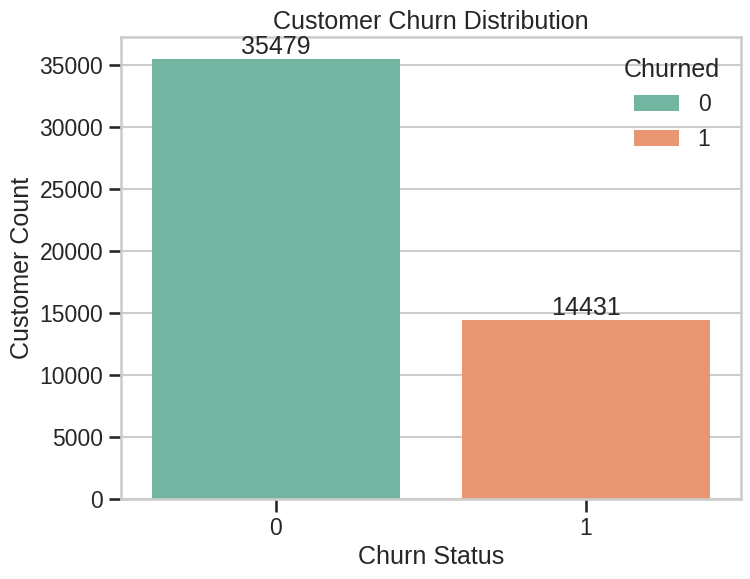

In [88]:
# Churn Distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(x="Churned",data=df,palette="Set2",hue="Churned")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

for i in ax.containers:
    ax.bar_label(i)

plt.show()



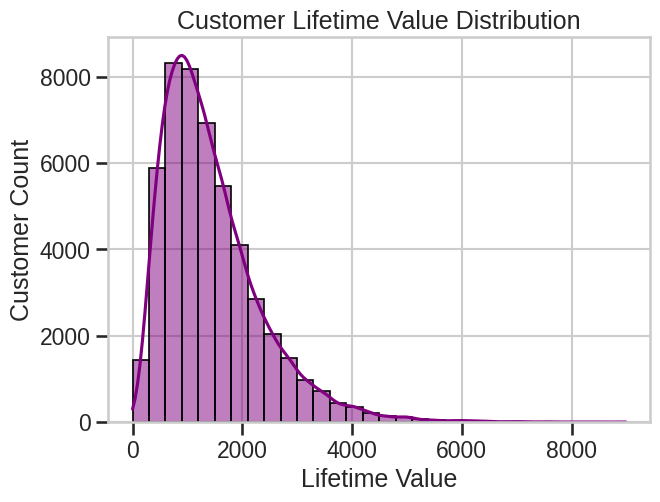

In [89]:
# customer lifetime value  distribution
plt.figure(figsize=(7,5))
sns.histplot(df["Lifetime_Value"],bins=30,kde=True,color="purple")
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Lifetime Value")
plt.ylabel("Customer Count")
plt.show()

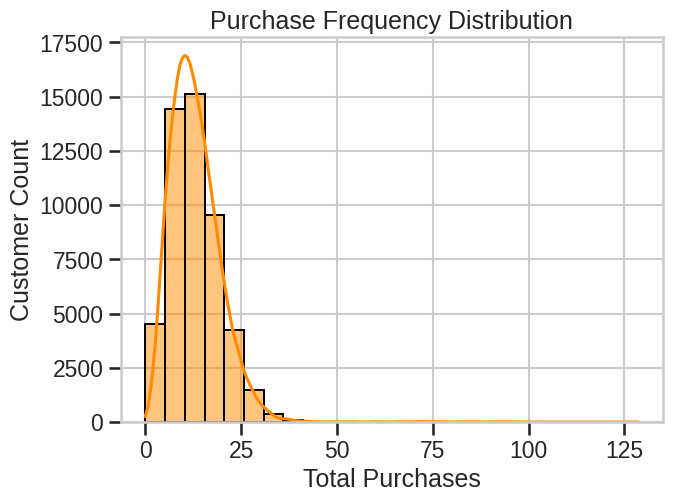

In [90]:
# Purches frequency distribution
plt.figure(figsize=(7,5))
sns.histplot(df["Total_Purchases"],bins=25,kde=True,color="darkorange")
plt.title("Purchase Frequency Distribution")
plt.xlabel("Total Purchases")
plt.ylabel("Customer Count")
plt.show()

## 4. Feature Engineering

Combine related raw columns into composite `Activity_Score` and `Engagement_Score` metrics, and derive an activity status label.

In [91]:
# Activity Score
df["Activity_Score"] = (
    df["Login_Frequency"] +
    df["Pages_Per_Session"] +
    df["Mobile_App_Usage"]
)

In [92]:
# Engagement Score
df["Engagement_Score"] = (
    df["Email_Open_Rate"] +
    df["Social_Media_Engagement_Score"] +
    df["Product_Reviews_Written"]
)

In [93]:
#create customerr activity
df["Activity_Status"] = pd.cut(
    df["Activity_Score"],
    bins=[0, 20, 40, float("inf")],
    labels=["Inactive","Moderately Active","Highly Active"]
)


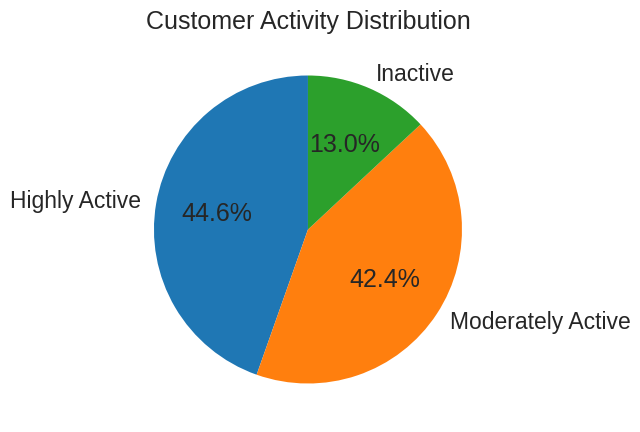

In [94]:
activity_counts = df["Activity_Status"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(
    activity_counts,
    labels=activity_counts.index,
    autopct="%1.1f%%",
    startangle=90
  )

plt.title("Customer Activity Distribution")
plt.show()

## 5. Churn Behavior Analysis

Compare engagement and behavior metrics between churned and retained customers.

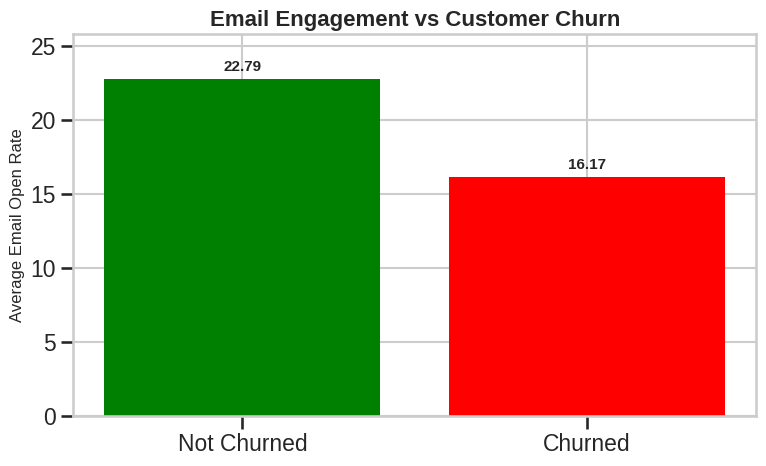

In [95]:
email_churn = df.groupby("Churned")["Email_Open_Rate"].mean()
plt.figure(figsize=(8,5))
bars = plt.bar(["Not Churned", "Churned"],email_churn.values,color=["green", "red"])
plt.title("Email Engagement vs Customer Churn",fontsize=16,fontweight="bold")
plt.ylabel("Average Email Open Rate",fontsize=12)
plt.ylim(0, max(email_churn.values) + 3)
for bar in bars:

    yval = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        yval + 0.5,

        round(yval,2),

        ha="center",

        fontsize=11,

        fontweight="bold"

    )

plt.tight_layout()

plt.show()

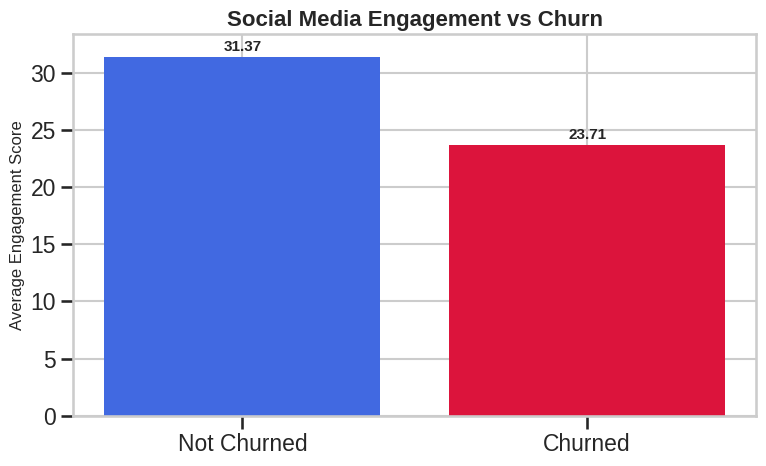

In [96]:
social_churn = df.groupby("Churned")["Social_Media_Engagement_Score"].mean()

plt.figure(figsize=(8,5))

bars = plt.bar(["Not Churned", "Churned"],

    social_churn.values,

    color=["royalblue", "crimson"]

)

plt.title("Social Media Engagement vs Churn",

    fontsize=16,

    fontweight="bold"

)

plt.ylabel("Average Engagement Score",fontsize=12)

plt.ylim(0, max(social_churn.values) + 2)

for bar in bars:

    yval = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        yval + 0.5,

        round(yval,2),

        ha="center",

        fontsize=11,

        fontweight="bold"

    )

plt.tight_layout()

plt.show()

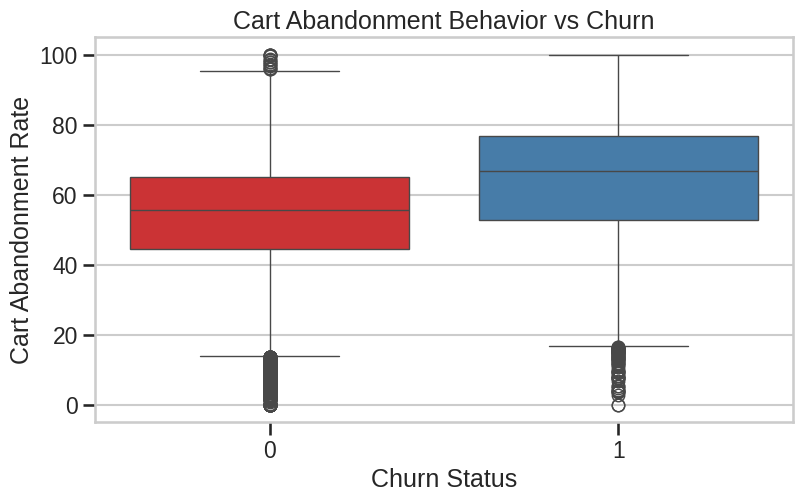

In [97]:
# charn vs cart abandonment
plt.figure(figsize=(9,5))

sns.boxplot(

    x="Churned",

    y="Cart_Abandonment_Rate",

    data=df,

    palette="Set1",

    hue="Churned",

    legend=False

)

plt.title("Cart Abandonment Behavior vs Churn")

plt.xlabel("Churn Status")

plt.ylabel("Cart Abandonment Rate")

plt.show()

## 6. Correlation Analysis

In [98]:
# correlationn annalysis
important_cols = [

    "Lifetime_Value",
    "Total_Purchases",
    "Login_Frequency",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Cart_Abandonment_Rate",
    "Engagement_Score",
    "Churned"

]

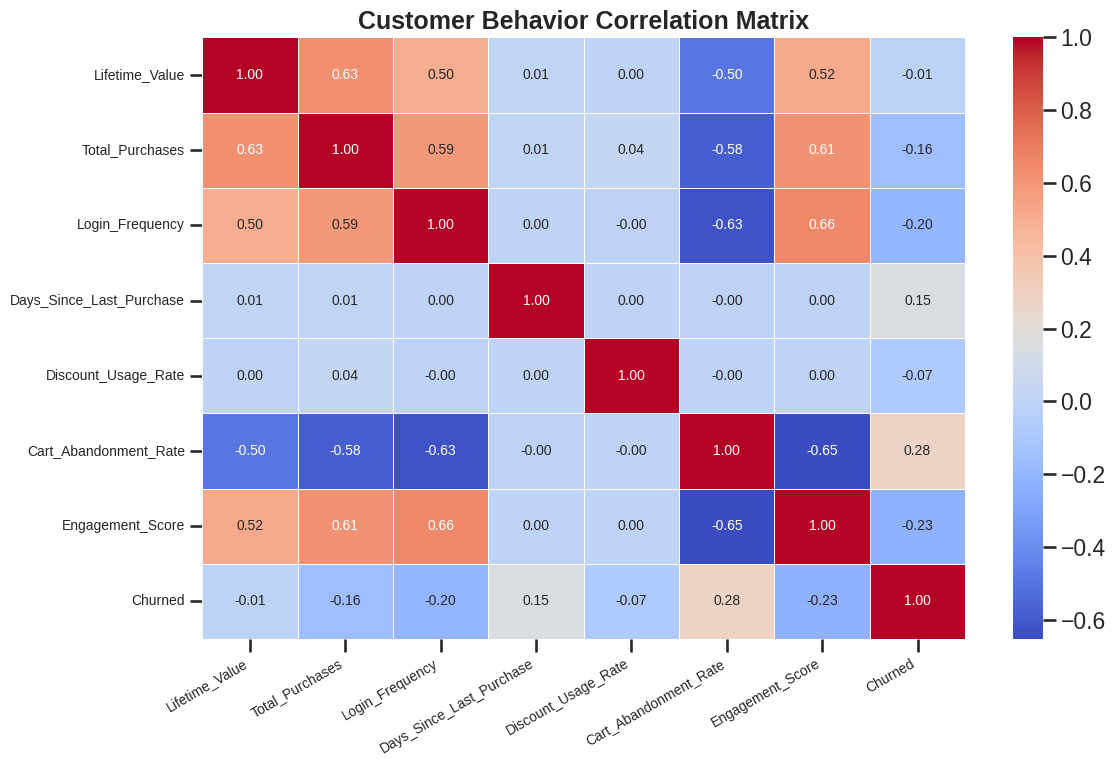

In [99]:
plt.figure(figsize=(12,8))
sns.heatmap(

    df[important_cols].corr(),

    annot=True,

    cmap="coolwarm",

    linewidths=0.5,

    fmt=".2f",

    annot_kws={"size":10}

)

plt.title("Customer Behavior Correlation Matrix",fontsize=18,fontweight="bold")
plt.xticks(rotation=30,ha="right",fontsize=10)
plt.yticks(rotation=0,fontsize=10)
plt.tight_layout()
plt.show()

## 7. K-Means Clustering

Select behavioral features, scale them, and determine the optimal number of clusters.

In [ ]:

# feature selection
features = [

    "Lifetime_Value",
    "Total_Purchases",
    "Login_Frequency",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Cart_Abandonment_Rate",
    "Engagement_Score"

]

X = df[features]

In [101]:
# feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [102]:
# Elbow method
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

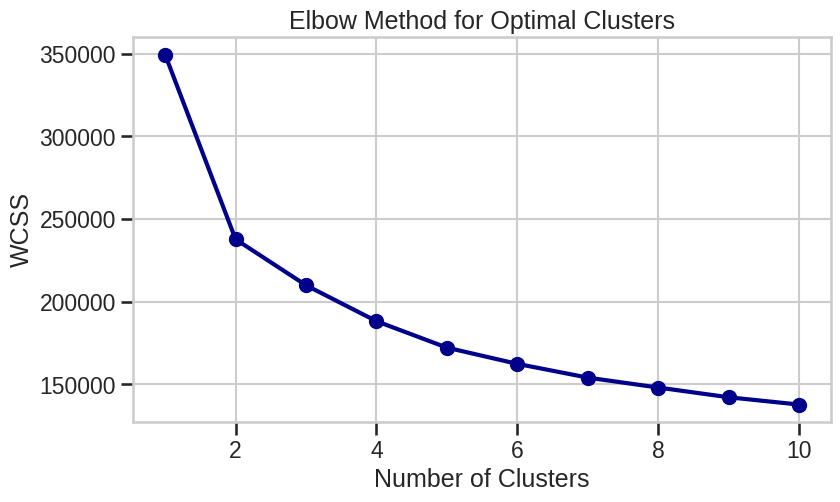

In [103]:
# plot elbow curve
plt.figure(figsize=(9,5))
plt.plot(range(1,11),wcss,marker="o",markersize=10,linewidth=3,color="darkblue")
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [104]:
# train K-means  model
kmeans = KMeans(n_clusters=5,random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [114]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for k=5: {sil_score:.3f}")

Silhouette Score for k=5: 0.179


## 8. Cluster Profiling & Segment Naming

Clusters are ranked by a composite score of value/engagement metrics and labeled programmatically — not hardcoded — so labels reflect actual cluster behavior rather than assumed cluster order.

In [105]:
cluster_summary = df.groupby("Cluster")[features].mean()

# Build a composite "value score" to rank clusters objectively.
# Higher Lifetime_Value + Total_Purchases + Login_Frequency = more valuable/engaged.
# Higher Cart_Abandonment_Rate + Days_Since_Last_Purchase = less engaged/at risk.
ranking_score = (
    cluster_summary["Lifetime_Value"].rank() +
    cluster_summary["Total_Purchases"].rank() +
    cluster_summary["Login_Frequency"].rank() +
    cluster_summary["Discount_Usage_Rate"].rank() -
    cluster_summary["Cart_Abandonment_Rate"].rank() -
    cluster_summary["Days_Since_Last_Purchase"].rank()
).sort_values(ascending=False)

# ranking_score.index is now ordered best -> worst cluster
ordered_clusters = ranking_score.index.tolist()

segment_labels = ["Loyal Customers", "Regular Customers", "Discount Seekers",
                   "Window Shoppers", "Inactive Customers"]

cluster_names = dict(zip(ordered_clusters, segment_labels))

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

print(cluster_names)  # sanity check — glance at this before trusting downstream charts

{2: 'Loyal Customers', 0: 'Regular Customers', 4: 'Discount Seekers', 3: 'Window Shoppers', 1: 'Inactive Customers'}


In [106]:
cluster_summary.style\
.background_gradient(cmap="Purples_r")\
.format("{:.2f}")

,Lifetime_Value,Total_Purchases,Login_Frequency,Days_Since_Last_Purchase,Discount_Usage_Rate,Cart_Abandonment_Rate,Engagement_Score
Cluster,,,,,,,
0,1620.99,14.73,14.15,20.92,32.51,51.77,61.62
1,806.39,7.62,5.38,22.51,33.03,70.25,28.52
2,2633.04,22.93,22.28,27.43,44.70,35.54,95.81
3,1317.13,12.15,10.51,96.99,40.63,58.86,48.59
4,1190.46,11.34,8.96,22.49,68.37,61.96,42.59


In [107]:
segment_summary = df.groupby("Customer_Segment")[features].mean()

In [108]:
segment_summary = segment_summary.loc[

    [

        "Loyal Customers",

        "Regular Customers",

        "Window Shoppers",

        "Discount Seekers",

        "Inactive Customers"

    ]

]

In [109]:
segment_summary.style\
.background_gradient(cmap="Blues")\
.format("{:.2f}")

,Lifetime_Value,Total_Purchases,Login_Frequency,Days_Since_Last_Purchase,Discount_Usage_Rate,Cart_Abandonment_Rate,Engagement_Score
Customer_Segment,,,,,,,
Loyal Customers,2633.04,22.93,22.28,27.43,44.70,35.54,95.81
Regular Customers,1620.99,14.73,14.15,20.92,32.51,51.77,61.62
Window Shoppers,1317.13,12.15,10.51,96.99,40.63,58.86,48.59
Discount Seekers,1190.46,11.34,8.96,22.49,68.37,61.96,42.59
Inactive Customers,806.39,7.62,5.38,22.51,33.03,70.25,28.52


## 9. Segment Visualization & Business Insights

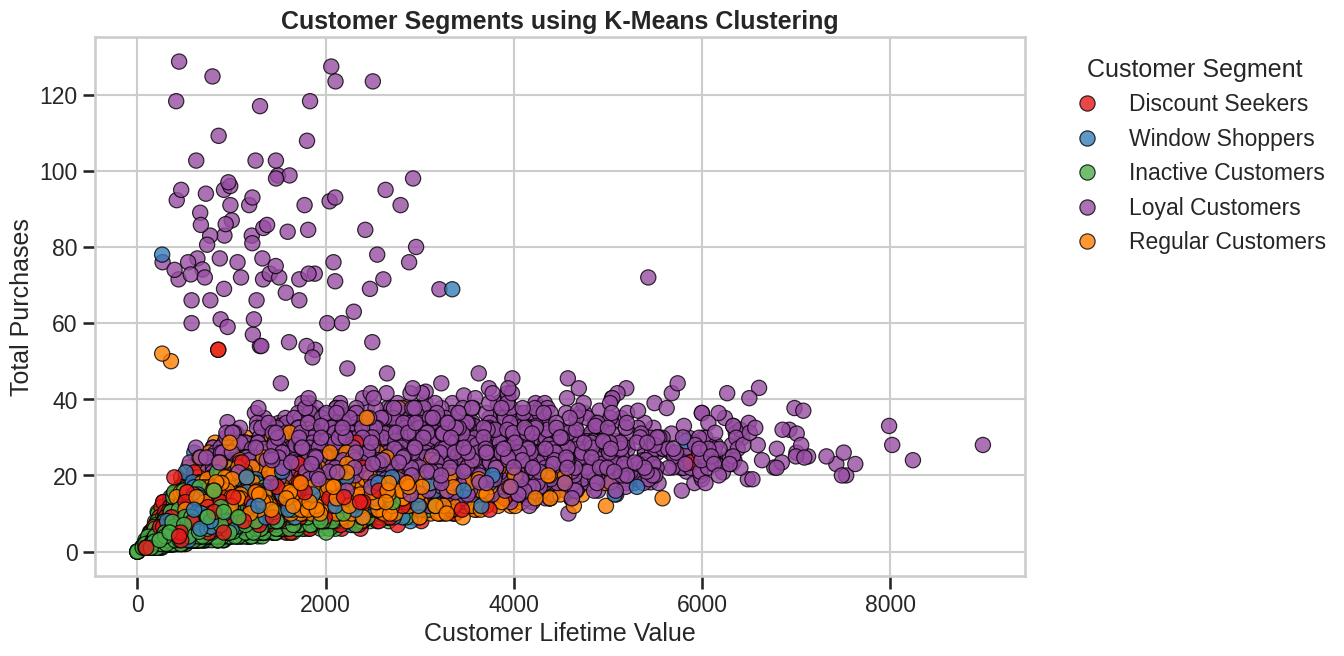

In [110]:
plt.figure(figsize=(12,7))

sns.scatterplot(

    x=df["Lifetime_Value"],

    y=df["Total_Purchases"],

    hue=df["Customer_Segment"],

    palette="Set1",

    s=120,

    alpha=0.8,

    edgecolor="black"

)

plt.title("Customer Segments using K-Means Clustering",fontsize=18,fontweight="bold")

plt.xlabel("Customer Lifetime Value")

plt.ylabel("Total Purchases")

plt.legend(title="Customer Segment",bbox_to_anchor=(1.02,1),loc="upper left")

plt.show()

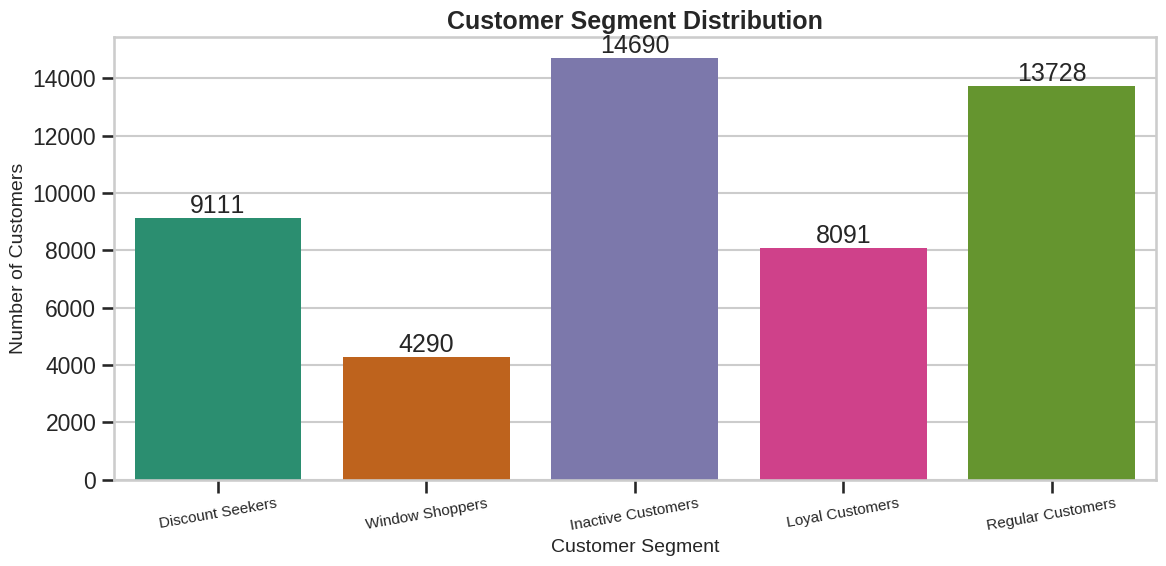

In [111]:
plt.figure(figsize=(12,6))

ax = sns.countplot(

    x="Customer_Segment",

    data=df,

    palette="Dark2",

    hue="Customer_Segment",

    legend=False

)

plt.title("Customer Segment Distribution",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Customer Segment",fontsize=14)

plt.ylabel("Number of Customers",fontsize=14)

plt.xticks(rotation=10,fontsize=11)

for i in ax.containers:

    ax.bar_label(i)

plt.tight_layout()

plt.show()

In [112]:
# Churn percentage within each customer segment

segment_churn = pd.crosstab(
    df["Customer_Segment"],
    df["Churned"],
    normalize="index"
) * 100

segment_churn = segment_churn.round(2)

segment_churn

Churned,0,1
Customer_Segment,,
Discount Seekers,79.62,20.38
Inactive Customers,59.77,40.23
Loyal Customers,78.26,21.74
Regular Customers,77.50,22.50
Window Shoppers,57.67,42.33


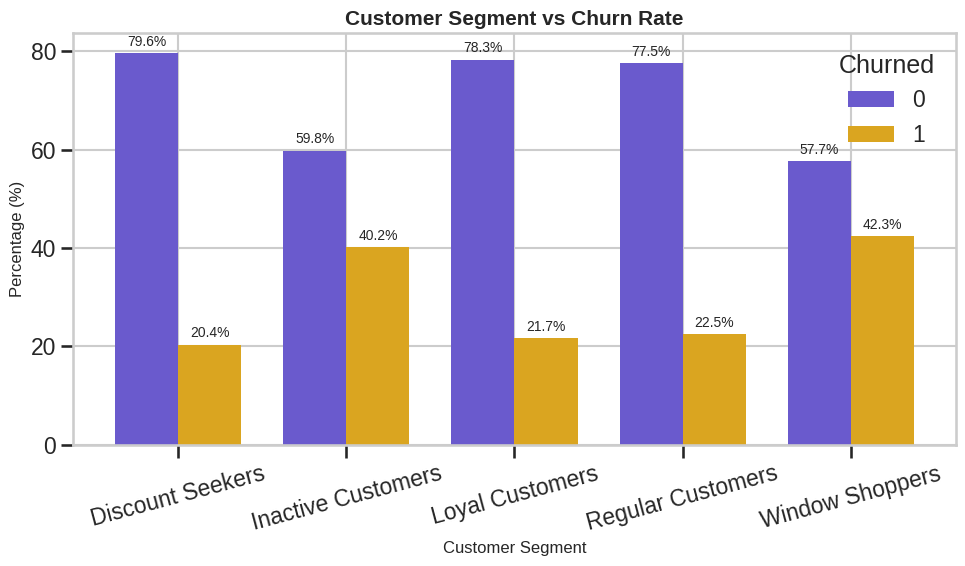

In [113]:
# Calculate churn percentage by segment

segment_churn = (
    pd.crosstab(
        df["Customer_Segment"],
        df["Churned"],
        normalize="index"
    ) * 100
).round(2)

# Plot grouped column chart

ax = segment_churn.plot(
    kind="bar",
    figsize=(10,6),
    color=["slateblue", "goldenrod"],
    width=0.75
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10)

plt.title("Customer Segment vs Churn Rate", fontsize=15, fontweight="bold")
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Churned")

plt.tight_layout()
plt.show()

## Conclusion

K-Means (k=5, chosen via the Elbow Method) segmented customers into five behavioral groups: **Loyal Customers, Regular Customers, Discount Seekers, Window Shoppers, and Inactive Customers**.

- **Silhouette Score: ~0.18**, indicating moderate cluster overlap — customer behavior in this dataset exists more on a continuum than in sharply distinct groups. The segments are still directionally useful for targeting, but should be interpreted as tendencies rather than hard boundaries.
- **Inactive Customers** and **Window Shoppers** show the highest churn rates, suggesting retention efforts (re-engagement emails, personalized offers) should prioritize these two segments.
- **Loyal Customers** and **Regular Customers** churn far less, and represent the base worth protecting through consistent service quality rather than aggressive incentives.

**Possible next steps:** try a supervised model (e.g. logistic regression or random forest) to predict churn directly and rank feature importance, or test alternate values of *k* against the silhouette score to see if a different cluster count separates segments more cleanly.